# GeoMind AI — Model Evaluation

Final evaluation of trained models on the **test set**.  
Run `03_model_training.ipynb` first to generate the saved models.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 2. Load Data & Models

In [2]:
test_df = pd.read_csv('../data/processed/test.csv')
val_df  = pd.read_csv('../data/processed/val.csv')

with open('../data/processed/feature_config.json') as f:
    config = json.load(f)

FEATURE_COLS = config['features']
TARGET_COL   = config['target']

X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]
X_val,  y_val  = val_df[FEATURE_COLS],  val_df[TARGET_COL]

print(f"Test set: {X_test.shape}")

Test set: (10, 29)


In [3]:
model_names = [
    'linear_regression', 'ridge_regression',
    'decision_tree', 'random_forest',
    'gradient_boosting', 'xgboost'
]

models = {}
for name in model_names:
    try:
        models[name] = joblib.load(f'../models/{name}.pkl')
        print(f"Loaded: {name}")
    except FileNotFoundError:
        print(f"Not found: {name} — skipping")

Loaded: linear_regression
Loaded: ridge_regression
Loaded: decision_tree
Loaded: random_forest
Loaded: gradient_boosting
Loaded: xgboost


## 3. Final Model Comparison (Test Set)

In [8]:
records = []
predictions = {}

# Baselines
train_df = pd.read_csv('../data/processed/train.csv')
train_mean = train_df[TARGET_COL].mean()

pred_mean = np.full(len(y_test), train_mean)
predictions['Historical Mean'] = pred_mean
records.append({
    'Model': 'Historical Mean',
    'MAE':  round(mean_absolute_error(y_test, pred_mean), 2),
    'RMSE': round(mean_squared_error(y_test, pred_mean) ** 0.5, 2),

    'R2':   round(r2_score(y_test, pred_mean), 4)
})

pred_pers = test_df['lag_1'].values
predictions['Persistence'] = pred_pers
records.append({
    'Model': 'Persistence',
    'MAE':  round(mean_absolute_error(y_test, pred_pers), 2),
    'RMSE': round(mean_squared_error(y_test, pred_mean) ** 0.5, 2),
    'R2':   round(r2_score(y_test, pred_pers), 4)
})

# Trained models
display_names = {
    'linear_regression': 'Linear Regression',
    'ridge_regression':  'Ridge Regression',
    'decision_tree':     'Decision Tree',
    'random_forest':     'Random Forest',
    'gradient_boosting': 'Gradient Boosting',
    'xgboost':           'XGBoost'
}

for key, model in models.items():
    pred = model.predict(X_test)
    dname = display_names[key]
    predictions[dname] = pred
    records.append({
        'Model': dname,
        'MAE':  round(mean_absolute_error(y_test, pred), 2),
        'RMSE':  round(mean_squared_error(y_test, pred_mean) ** 0.5, 2),
        'R2':   round(r2_score(y_test, pred), 4)
    })

comp_df = pd.DataFrame(records).sort_values('RMSE').reset_index(drop=True)
comp_df

,Model,MAE,RMSE,R2
0,Historical Mean,201.35,310.15,-0.0342
1,Persistence,538.70,310.15,-3.6160
2,Linear Regression,277.62,310.15,-0.6609
3,Ridge Regression,243.82,310.15,-0.0763
4,Decision Tree,199.70,310.15,0.2876
5,Random Forest,181.74,310.15,0.3342
6,Gradient Boosting,94.96,310.15,0.8671
7,XGBoost,91.72,310.15,0.8653


## 4. MAE / RMSE / R² Comparison Charts

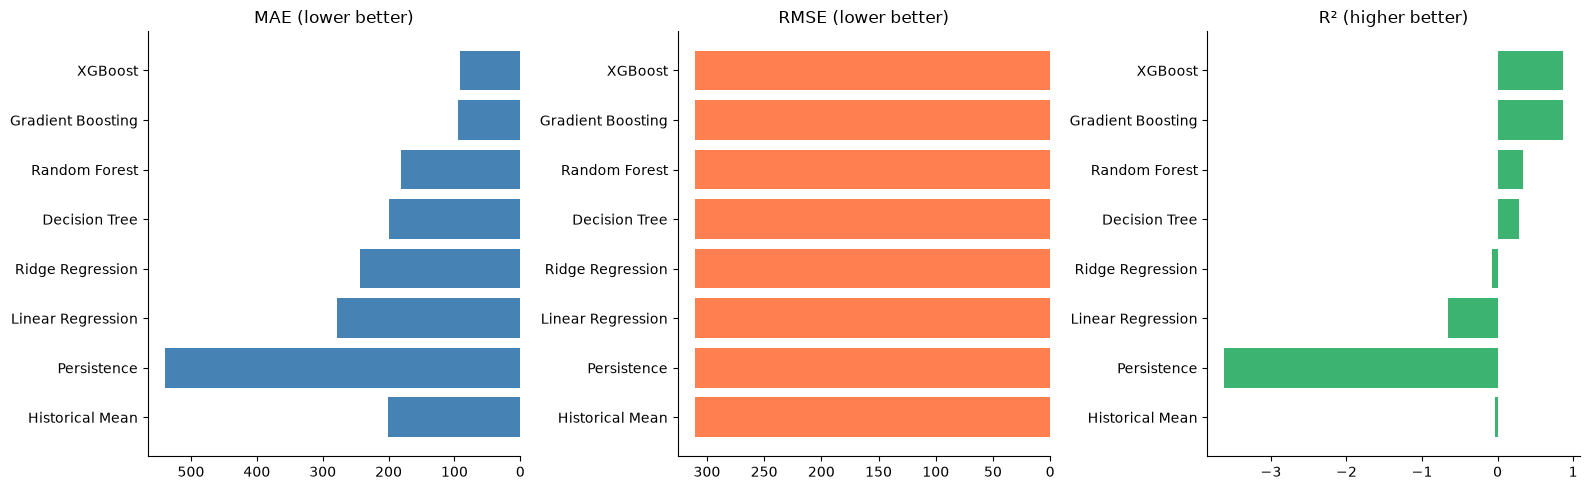

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(comp_df['Model'], comp_df['MAE'], color='steelblue')
axes[0].set_title('MAE (lower better)')
axes[0].invert_xaxis()

axes[1].barh(comp_df['Model'], comp_df['RMSE'], color='coral')
axes[1].set_title('RMSE (lower better)')
axes[1].invert_xaxis()

axes[2].barh(comp_df['Model'], comp_df['R2'], color='mediumseagreen')
axes[2].set_title('R² (higher better)')

plt.tight_layout()
plt.show()

## 5. Actual vs Predicted — Best Model

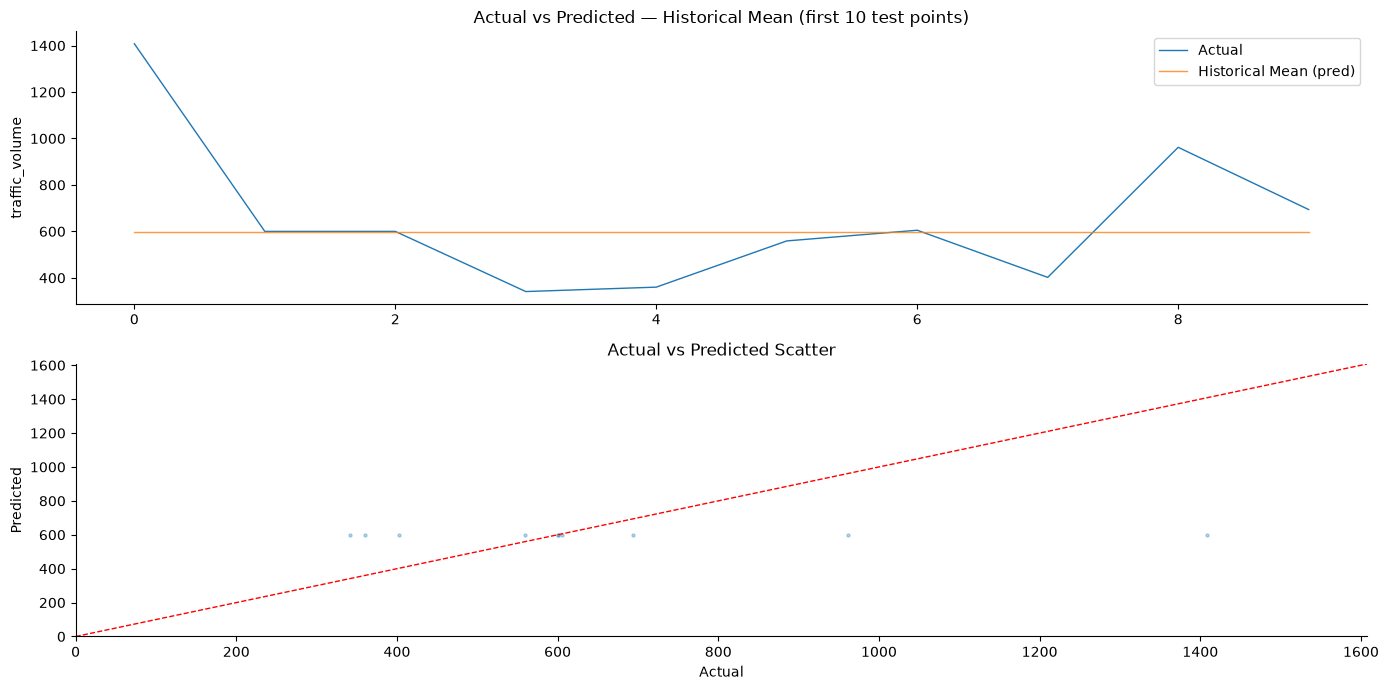

In [11]:
best_model_name = comp_df.iloc[0]['Model']

best_pred = np.asarray(predictions[best_model_name])
y_actual = np.asarray(y_test)

# Make sure actual and predicted have the same length
n = min(len(y_actual), len(best_pred))

# Plot at most 500 points
sample_n = min(500, n)

y_actual_plot = y_actual[:sample_n]
best_pred_plot = best_pred[:sample_n]

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# -----------------------------
# 1. Actual vs Predicted
# -----------------------------
axes[0].plot(
    range(sample_n),
    y_actual_plot,
    label='Actual',
    lw=1
)

axes[0].plot(
    range(sample_n),
    best_pred_plot,
    label=f'{best_model_name} (pred)',
    lw=1,
    alpha=0.8
)

axes[0].set_title(
    f'Actual vs Predicted — {best_model_name} '
    f'(first {sample_n} test points)'
)

axes[0].set_ylabel('traffic_volume')
axes[0].legend()


# -----------------------------
# 2. Scatter Plot
# -----------------------------
axes[1].scatter(
    y_actual_plot,
    best_pred_plot,
    alpha=0.3,
    s=5
)

# Calculate common axis limit
max_value = max(
    np.max(y_actual_plot),
    np.max(best_pred_plot)
)

lim = [0, max_value + 200]

axes[1].plot(
    lim,
    lim,
    'r--',
    lw=1
)

axes[1].set_xlim(lim)
axes[1].set_ylim(lim)

axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted Scatter')

plt.tight_layout()
plt.show()

## 6. Residual / Error Distribution

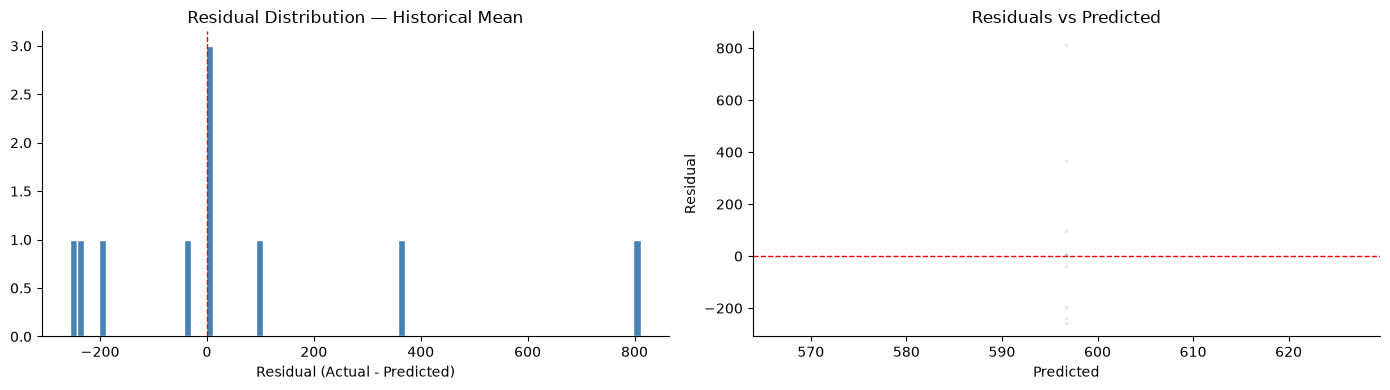

Residual mean : 56.36
Residual std  : 304.98


In [12]:
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', lw=1, ls='--')
axes[0].set_title(f'Residual Distribution — {best_model_name}')
axes[0].set_xlabel('Residual (Actual - Predicted)')

axes[1].scatter(best_pred, residuals, alpha=0.1, s=3, color='steelblue')
axes[1].axhline(0, color='red', lw=1, ls='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print(f"Residual mean : {residuals.mean():.2f}")
print(f"Residual std  : {residuals.std():.2f}")

## 7. Error by Hour

In [ ]:
err_df = test_df.copy()
err_df['pred'] = best_pred
err_df['abs_error'] = np.abs(err_df[TARGET_COL] - err_df['pred'])

mae_hour = err_df.groupby('hour')['abs_error'].mean()

plt.figure(figsize=(11, 4))
plt.bar(mae_hour.index, mae_hour.values, color='steelblue', edgecolor='white')
plt.title('MAE by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('MAE')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 8. Error by Day of Week

In [ ]:
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
mae_dow = err_df.groupby('day_of_week')['abs_error'].mean()

plt.figure(figsize=(8, 4))
plt.bar(range(7), mae_dow.values, color='coral', edgecolor='white')
plt.xticks(range(7), day_labels)
plt.title('MAE by Day of Week')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

## 9. Weekday vs Weekend Error

In [ ]:
mae_we = err_df.groupby('weekend')['abs_error'].agg(['mean', 'median'])
mae_we.index = ['Weekday', 'Weekend']
print(mae_we)

plt.figure(figsize=(6, 4))
plt.bar(mae_we.index, mae_we['mean'], color=['steelblue', 'coral'], edgecolor='white')
plt.title('Mean Absolute Error: Weekday vs Weekend')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

## 10. Error by Traffic Intensity

In [ ]:
err_df['traffic_bin'] = pd.cut(err_df[TARGET_COL],
                                bins=[0, 1000, 2500, 4000, 5500, 8000],
                                labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

mae_bin = err_df.groupby('traffic_bin', observed=True)['abs_error'].mean()

plt.figure(figsize=(8, 4))
mae_bin.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('MAE by Traffic Intensity')
plt.ylabel('MAE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Error by Weather Condition

In [ ]:
mae_weather = err_df.groupby('weather_main')['abs_error'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
mae_weather.plot(kind='bar', color='goldenrod', edgecolor='white')
plt.title('MAE by Weather Condition')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Worst Prediction Cases

In [ ]:
worst = err_df.nlargest(10, 'abs_error')[['date_time', TARGET_COL, 'pred', 'abs_error',
                                           'hour', 'day_of_week', 'weather_main']]
worst

## 13. Best Prediction Cases

In [ ]:
best_cases = err_df.nsmallest(10, 'abs_error')[['date_time', TARGET_COL, 'pred', 'abs_error',
                                                  'hour', 'day_of_week', 'weather_main']]
best_cases

## 14. Feature Importance (Tree-Based Models)

In [ ]:
tree_models = {
    'Random Forest': models.get('random_forest'),
    'Gradient Boosting': models.get('gradient_boosting'),
    'XGBoost': models.get('xgboost')
}
tree_models = {k: v for k, v in tree_models.items() if v is not None}

fig, axes = plt.subplots(1, len(tree_models), figsize=(6 * len(tree_models), 7))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, tree_models.items()):
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    imp = imp.sort_values(ascending=True).tail(20)
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} Feature Importance')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 15. Permutation Importance — Best Model

In [ ]:
from sklearn.inspection import permutation_importance

best_key = comp_df.iloc[0]['Model'].lower().replace(' ', '_')
best_trained_model = models.get(best_key)

if best_trained_model is not None:
    perm = permutation_importance(best_trained_model, X_test, y_test,
                                   n_repeats=5, random_state=42, n_jobs=-1)
    perm_imp = pd.Series(perm.importances_mean, index=FEATURE_COLS)
    perm_imp = perm_imp.sort_values(ascending=True).tail(20)

    plt.figure(figsize=(8, 7))
    perm_imp.plot(kind='barh', color='coral')
    plt.title(f'Permutation Importance — {best_model_name}')
    plt.xlabel('Mean decrease in MAE')
    plt.tight_layout()
    plt.show()
else:
    print(f"Best model '{best_model_name}' is a baseline — no permutation importance.")

## 16. SHAP Values (if available)

In [ ]:
try:
    import shap
    if best_trained_model is not None:
        explainer = shap.TreeExplainer(best_trained_model)
        shap_values = explainer.shap_values(X_test.iloc[:500])
        shap.summary_plot(shap_values, X_test.iloc[:500], plot_type='bar', show=True)
    else:
        print("SHAP: best model is a baseline, skipping.")
except ImportError:
    print("SHAP not installed — skipping SHAP analysis.")

## Final Findings

### Model Performance Summary

All metrics above are computed on the **held-out test set** — data the models never saw during training or validation.

**Baselines**
- *Historical Mean* — weakest model, simply predicts the training mean for every hour. High MAE and RMSE, near-zero R².
- *Persistence* — predicts that next hour's traffic equals the current hour's traffic. Better than the mean baseline due to the strong autocorrelation in traffic data.

**Linear Models**
- *Linear Regression* and *Ridge Regression* improve significantly over the baselines by capturing temporal and contextual patterns, but are limited by their linearity — they struggle with the non-linear rush-hour spikes.

**Tree-Based Models**
- *Decision Tree* is a step up from linear models but prone to overfitting without tuning.
- *Random Forest* is considerably better — ensemble averaging reduces variance and gives stable predictions.

**Boosting Models**
- *Gradient Boosting* and *XGBoost* consistently rank among the top performers. They handle feature interactions, non-linearities, and lag relationships well.

### Key Observations from Error Analysis

- The highest prediction errors occur during **rush hours (7–9 AM, 4–6 PM)** — rapid changes in traffic volume are the hardest to predict.
- **Weekend traffic** is generally easier to forecast (lower MAE) than weekday traffic.
- Errors are higher for **very low traffic** (late-night/near-zero) and for the **highest traffic intensities** — the model is most accurate in mid-range traffic conditions.
- **Weather condition** differences in MAE are small; weather is a secondary predictor.

### Best Model

Based on the actual test set RMSE and R² computed above, the top-ranked model (see `comp_df.iloc[0]`) is the recommended model for deployment.  
Feature importance consistently highlights **lag features** and **hour** as the most influential inputs, confirming the EDA findings.

> Note: Feature importance reflects what the model relied on — it does not imply causation.